# DBSCAN Demo

 - Course Title: Problem Solving Using Pattern Recognition
 - Lecturer: Charles Pang
 - Copyright 2025 National University of Singapore
 - Jupyter Notebook v 7.1.2
 - Python 3.12.2 (!python --version)
 - scikit-learn 1.4.2 (!pip show scikit-learn)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
diabetes_data = pd.read_csv('diabetes_imputed.csv')
cols = list(diabetes_data)
diabetes_data.shape

(768, 9)

#### Prepare data

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
df_std = StandardScaler().fit_transform(diabetes_data)
#df_std = MinMaxScaler().fit_transform(df)

#### Observe trends in the data

In [ ]:
#observe trends in the data
# -----------------------------
# Matplotlib: 3×3 histogram grid
# -----------------------------
# Use a data-driven bin count for histogram (Freedman–Diaconis -- balances resolution/detail vs noise)
def _fd_bins(data: np.ndarray, *, min_bins: int = 4, max_bins: int = 10) -> int:
    # h = 2 * IQR(data) * numOfSamples^(-1/3) = FD bin width
    # IQR = 75th Quartile - 25th Quartile -- robust to outliers since ignores std
    # Theory: n^(-1/3) term comes from minimizing the asymptotic mean integrated squared error of the histogram as a density estimator.
    x = np.asarray(data)
    x = x[~np.isnan(x)]  #remove all NaN values, by selecting only those elements which are False in isnan
    #if just 1 datapoint OR all values almost the same, return min_bins
    #x.size is same as len(x)
    if x.size < 2 or np.allclose(x.min(), x.max()):
        return min_bins
    #'*' is unpacking operator, unpacks the two outputs [75th percentile, 25th percentile] so they can be subtracted
    iqr = np.subtract(*np.percentile(x, [75, 25]))  #equivalent to p.percentile(x, 75) - np.percentile(x, 25)
    iqr = max(iqr, 1e-12)  #avoid zero or infinitesimal - cases where data almost all similar
    h = 2 * iqr * (x.size ** (-1 / 3) + 1e-9)
    h = max(h, 1e-12)  #avoid zero
    # number of bins ≈ (max x - min x)/h
    numbins = int(np.ceil((x.max() - x.min()) / h))
    return int(np.clip(numbins, min_bins, max_bins))  #ensure result within the bounds


def gridplot_mlp(bufferdf: pd.DataFrame, buftitle: str = "3x3 Gridplot for dataframe") -> plt.Figure:
    cols = bufferdf.select_dtypes(include=[np.number]).columns[:].tolist()  #get ALL 'number' columns names in list form
    fig, axes = plt.subplots(3, 3, figsize=(10, 8))
    axes = axes.ravel()  #flattens axes array from 2D 3x3 to 1D array with 9 elements so we can iterate over them in a single loop instead of needing nested loop
    for ax, c in zip(axes, cols):
        x = bufferdf[c].dropna().values
        ax.hist(x, bins=_fd_bins(x))
        ax.set_title(c, fontsize=10)
        ax.tick_params(labelsize=8)

    fig.suptitle(buftitle, fontsize=12)
    fig.tight_layout()
    # plt.show()
    return fig


bufv = gridplot_mlp(diabetes_data, "Diabetes — 9 histograms (Matplotlib)")
diabetes_data[cols].melt(var_name="Variable", value_name="Value")

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# -----------------------------
# Plotly: 3×3 histogram grid
# -----------------------------
cols = diabetes_data.select_dtypes(include=[np.number]).columns[
    :].tolist()  #get ALL 'number' columns names in list form
fig = make_subplots(rows=3, cols=3, subplot_titles=cols, horizontal_spacing=0.08, vertical_spacing=0.1)

for i, c in enumerate(cols, start=1):  #enumerate cols with numbers starting from 1
    r = (i - 1) // 3 + 1
    k = (i - 1) % 3 + 1
    x = diabetes_data[c].dropna().values

    # Let Plotly choose bins auto, else can also use nbinsx
    hist = go.Histogram(
        x=x,
        nbinsx=None,
        autobinx=True,
        name=c,
        showlegend=False
    )
    fig.add_trace(hist, row=r, col=k)

fig.update_layout(
    title="Diabetes — 9 histograms (Plotly)",
    height=800, width=1000
)
fig.update_xaxes(title_text="value")
fig.update_yaxes(title_text="count")
display(fig)

# DBSCAN

Min Points: 18


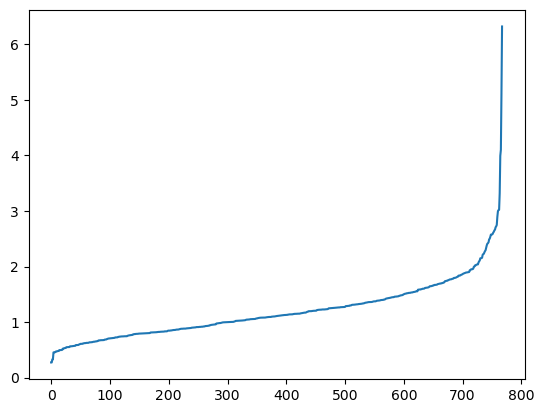

In [8]:
from sklearn.cluster import DBSCAN
# To estimate the minpts and epsilon, read this article
# https://medium.com/@tarammullin/dbscan-parameter-estimation-ff8330e3a3bd

# Obtaining the Min pts using Cols X 2
minpoints = 2 * df_std.shape[1]

# Finding the epsilon using NN with minpoints
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=minpoints)
neighbors_fit = neighbors.fit(df_std)
distances, indices = neighbors_fit.kneighbors(df_std)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)
print('Min Points:', minpoints)

In [38]:
#examine the scree plot, locate an elbow value on the y-axis.
epsilon = 2.0
minpoints = 20

In [39]:
dbsc = DBSCAN(eps = epsilon, min_samples = minpoints).fit(df_std)

labels = dbsc.labels_ #cluster labels for each datapoint
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Minpts=",minpoints,'   Epsilon=',epsilon)
print('Number of clusters: %d' % n_clusters_)
print('Number of noise points: %d' % n_noise_)

diabetes_data['cluster_db'] = labels.tolist() # add the cluster label as a col to original data
ccount = diabetes_data.groupby('cluster_db')['cluster_db'].count()
cluster_table = diabetes_data.groupby(['cluster_db']).agg('mean')
cluster_table['count'] = ccount
display(np.round(cluster_table,decimals=3))
#cluster_table.to_csv('clusters.csv')

Minpts= 20    Epsilon= 2.0
Number of clusters: 2
Number of noise points: 127


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,count
cluster_db,,,,,,,,,,
-1,4.748,142.850,78.906,33.093,244.698,36.111,0.770,41.370,0.614,127
0,3.220,108.162,70.091,26.696,110.720,30.504,0.390,30.091,0.000,451
1,4.726,139.516,73.234,31.802,187.645,34.468,0.466,35.284,1.000,190


In [29]:
## show indexes grouped by cluters:
from collections import defaultdict

cluster_dict = defaultdict(list)
for idx, label in enumerate(labels):
    cluster_dict[label].append(idx)

for cluster_id, indices in cluster_dict.items():
    print(f"\nCluster {cluster_id} has {len(indices)} points:")


Cluster 0 has 698 points:

Cluster -1 has 70 points:


### Visualise with any two of the columns:

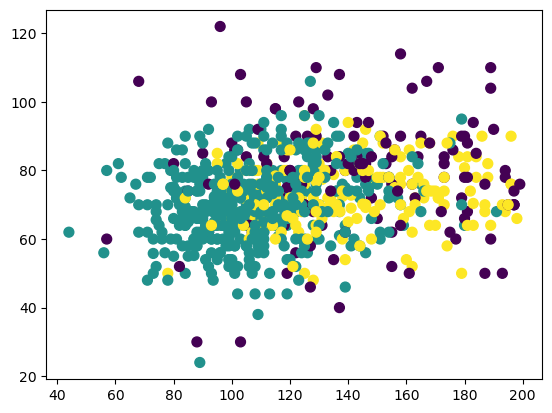

In [40]:
plt.scatter(diabetes_data['Glucose'], diabetes_data['BloodPressure'], c=labels, cmap='viridis', s=50)

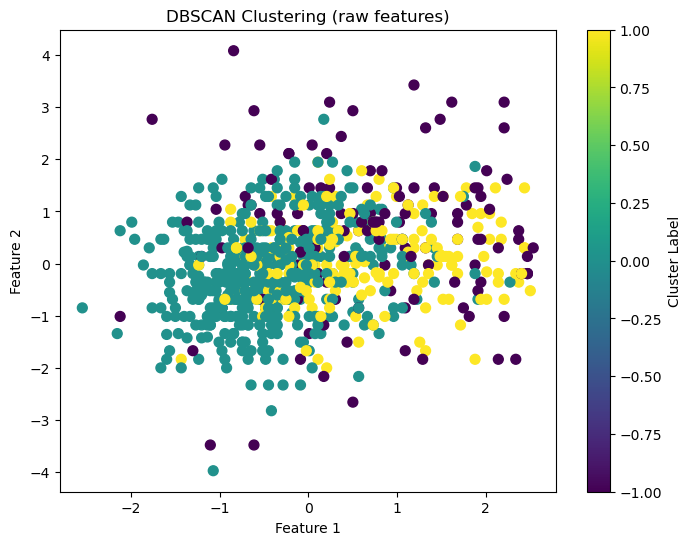

In [41]:
plt.figure(figsize=(8,6))
#same as above, Glucose is 1, BloodPressure is 2
plt.scatter(df_std[:, 1], df_std[:, 2], c=labels, cmap='viridis', s=50)
plt.title(f'DBSCAN Clustering (raw features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
plt.show()

### Visualise 2D scatter plot using PCA+Matplotlib

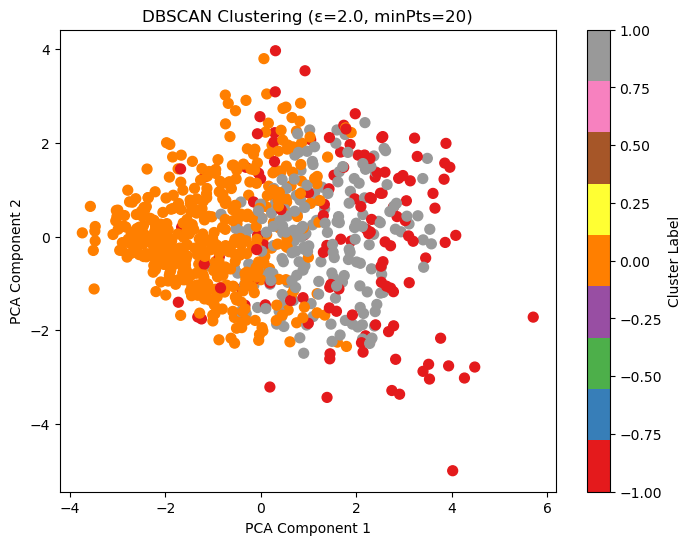

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_std)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='Set1', s=50)
#other cmap options: 'tab10' / 'viridis'
plt.title(f'DBSCAN Clustering (ε={epsilon}, minPts={minpoints})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

### Visualise t-SNE for Non-linear Dimensionality Reduction

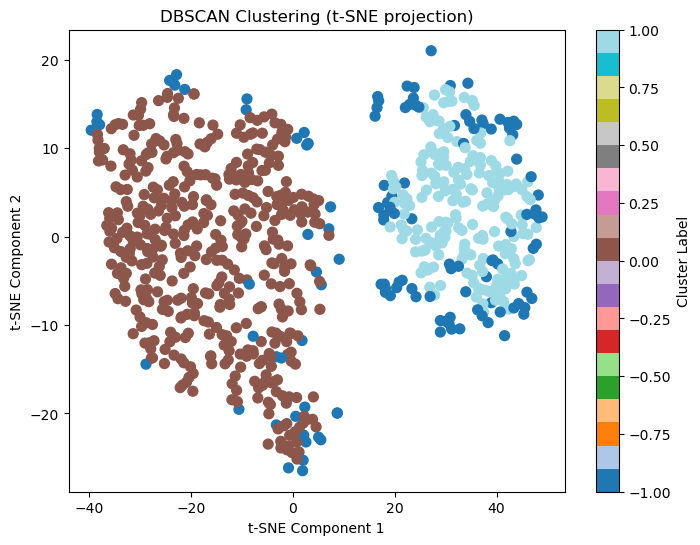

In [43]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
df_tsne = tsne.fit_transform(df_std)

plt.figure(figsize=(8,6))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1], c=labels, cmap='tab20', s=50)
plt.title(f'DBSCAN Clustering (t-SNE projection)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

## Use an automated way to detect elbow

Estimated epsilon (ε) using automated elbow detection: 2.1917


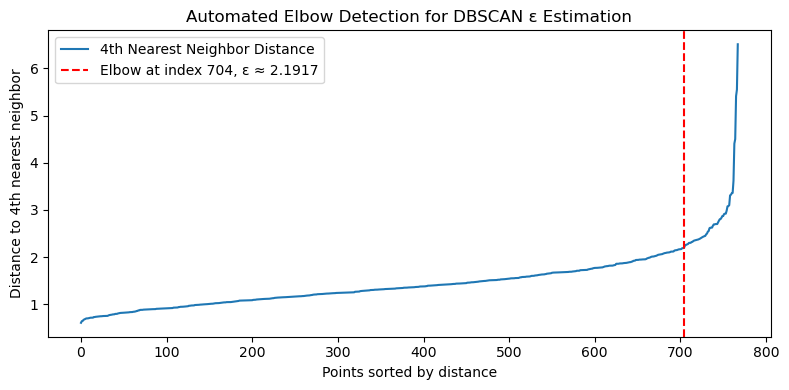

In [35]:
X = df_std.copy()

# Compute the distances to the minpoints nearest neighbor
neighbors = NearestNeighbors(n_neighbors=minpoints)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort the distances to the 4th nearest neighbor
k_distances = np.sort(distances[:, 3])

# Automated elbow detection using curvature method
def find_elbow_point(distances):
    n_points = len(distances)
    all_coords = np.vstack((range(n_points), distances)).T
    first_point = all_coords[0]
    last_point = all_coords[-1]

    line_vec = last_point - first_point
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    vec_from_first = all_coords - first_point
    scalar_product = np.dot(vec_from_first, line_vec_norm)
    proj = np.outer(scalar_product, line_vec_norm)
    vec_to_line = vec_from_first - proj
    dist_to_line = np.linalg.norm(vec_to_line, axis=1)

    elbow_index = np.argmax(dist_to_line)
    return elbow_index, distances[elbow_index]

elbow_index, epsilon = find_elbow_point(k_distances)

# Plot the k-distance graph with the detected elbow
plt.figure(figsize=(8, 4))
plt.plot(k_distances, label='4th Nearest Neighbor Distance')
plt.axvline(x=elbow_index, color='r', linestyle='--', label=f'Elbow at index {elbow_index}, ε ≈ {epsilon:.4f}')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 4th nearest neighbor')
plt.title('Automated Elbow Detection for DBSCAN ε Estimation')
plt.legend()
plt.tight_layout()
plt.savefig("automated_elbow_detection.png")

# Output the estimated epsilon value
print(f"Estimated epsilon (ε) using automated elbow detection: {epsilon:.4f}")


In [36]:
dbsc = DBSCAN(eps = epsilon, min_samples = minpoints).fit(df_std)

labels = dbsc.labels_ #cluster labels for each datapoint
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Minpts=",minpoints,'   Epsilon=',epsilon)
print('Number of clusters: %d' % n_clusters_)
print('Number of noise points: %d' % n_noise_)

diabetes_data['cluster_db'] = labels.tolist() # add the cluster label as a col to original data
ccount = diabetes_data.groupby('cluster_db')['cluster_db'].count()
cluster_table = diabetes_data.groupby(['cluster_db']).agg('mean')
cluster_table['count'] = ccount
display(np.round(cluster_table,decimals=3))
#cluster_table.to_csv('clusters.csv')

Minpts= 18    Epsilon= 2.1917207363956366
Number of clusters: 1
Number of noise points: 70


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,count
cluster_db,,,,,,,,,,
-1,4.157,146.157,78.900,34.617,282.757,37.407,0.854,40.300,0.543,70
0,3.814,119.198,71.667,28.456,138.784,31.911,0.434,32.533,0.330,698


### Visualise 2D scatter plot using PCA+Matplotlib

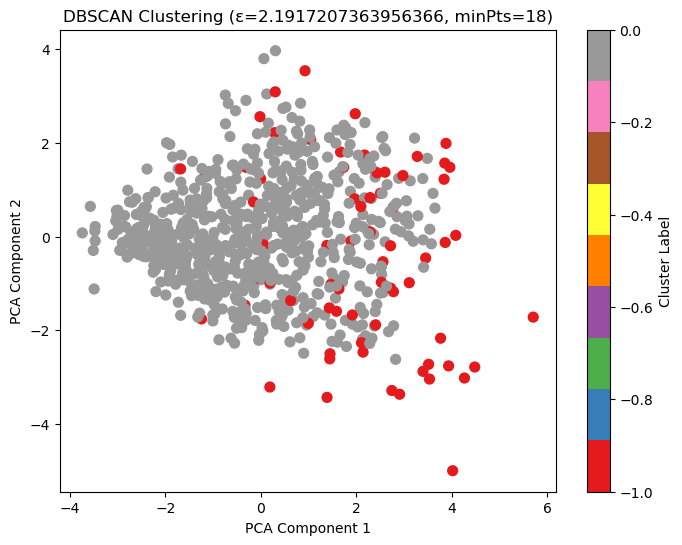

In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_std)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='Set1', s=50)
#other cmap options: 'tab10' / 'viridis'
plt.title(f'DBSCAN Clustering (ε={epsilon}, minPts={minpoints})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

### Visualise t-SNE for Non-linear Dimensionality Reduction

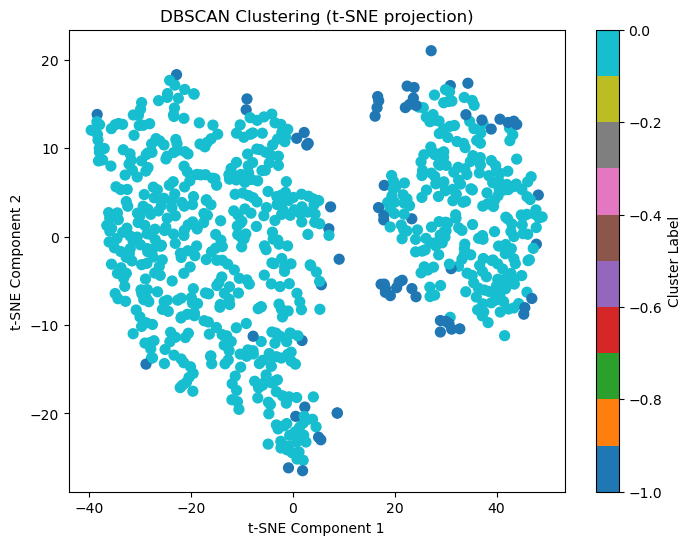

In [13]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
df_tsne = tsne.fit_transform(df_std)

plt.figure(figsize=(8,6))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1], c=labels, cmap='tab10', s=50)
plt.title(f'DBSCAN Clustering (t-SNE projection)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster Label')
plt.show()